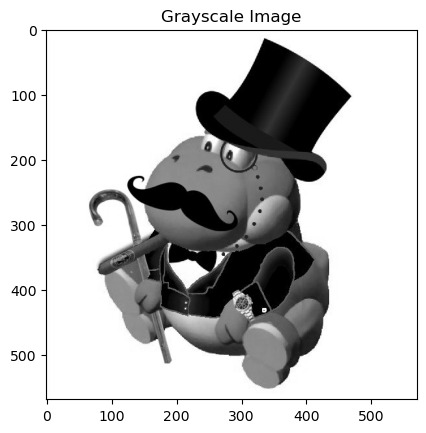

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline

# Load image
im = mpimg.imread("finishedfinishedbeegyoshifinishedfinished.jpg")

# Convert to grayscale
# Weighted luminance formula: human eyes are most sensitive to green
gray = np.dot(im, [0.299, 0.587, 0.144])
plt.imshow(gray, cmap=plt.get_cmap("gray"))
plt.title("Grayscale Image")
plt.show()

# Split into 8x8 tiles
height, width = gray.shape
eight = 8       # 
tiles = {}      # { (tile_x, tile_y): 8x8 array }

for y in range(0, height, eight):
    for x in range(0, width, eight):
        tile = gray[y:y+eight, x:x+eight]
        # Only keep tiles that fill a full 8x8 block; skip partial edge tiles
        if tile.shape == (eight, eight):
            tiles[(x // eight, y // eight)] = tile


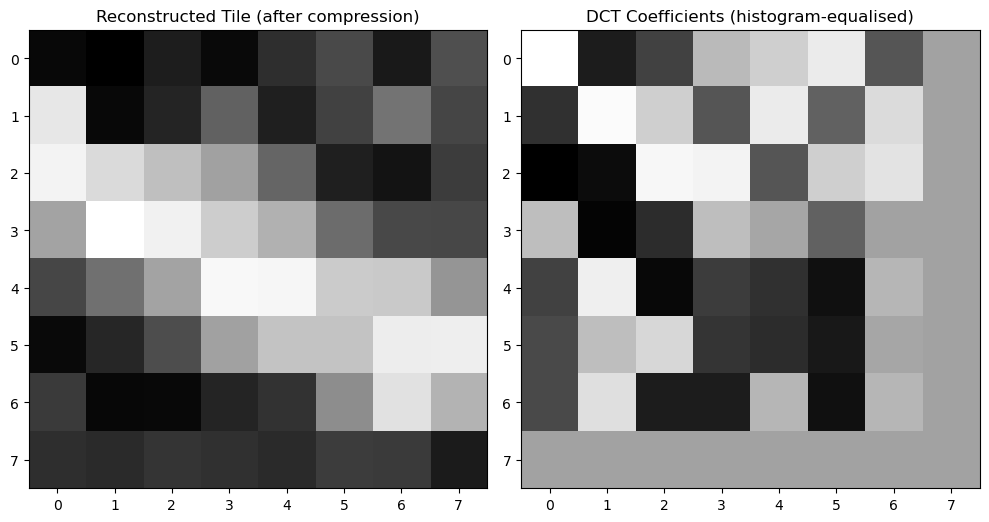

In [39]:
from scipy.fftpack import dct, idct

dct_tiles = {}   # Visualised DCT coefficient blocks
new_tiles = {}   # Reconstructed pixel values after filtering


def visualize_dct(d):
    d_max = d.max()
    if d_max == 0:
        # avoid divide-by-zero on blank tiles
        return np.zeros(d.shape) 

    # Shift so all values are non-negative
    d_shifted = d + abs(d.min()) 
    d_shifted_max = d_shifted.max()

    # Build cumulative histogram and remap values to [0, 255] so color is visible
    h = np.histogram(d_shifted, bins=1000, range=(0, d_shifted_max))
    c = 255.0 * np.cumsum(h[0]) / sum(h[0])

    new_img = np.zeros(d.shape)
    for index, value in np.ndenumerate(d_shifted):
        bin_idx = int(999.0 * value / d_shifted_max)
        new_img[index] = c[min(bin_idx, 999)]   # min() prevents index out-of-bounds
    return new_img


for key, tile in tiles.items():

    # 2D DCT: apply to rows then columns
    dct_2d = dct(dct(tile, axis=0, norm="ortho"), axis=1, norm="ortho")

    # Low-pass filter: zero out high-frequency coefficients
    # In an 8x8 block, positions (x > 6) or (y > 6) are the highest frequencies.
    for y in range(eight):
        for x in range(eight):
            if x > 6 or y > 6:
                dct_2d[y][x] = 0

    # Store both outputs
    new_tiles[key] = idct(idct(dct_2d, axis=1, norm="ortho"), axis=0, norm="ortho")
    dct_tiles[key] = visualize_dct(dct_2d)


# Preview a single tile
index = (25, 50)   # (tile_x, tile_y)
if index in new_tiles:
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].set_title("Reconstructed Tile (after compression)")
    axes[0].imshow(new_tiles[index], cmap="gray")
    axes[1].set_title("DCT Coefficients (histogram-equalised)")
    axes[1].imshow(dct_tiles[index], cmap="gray")
    plt.tight_layout()
    plt.show()


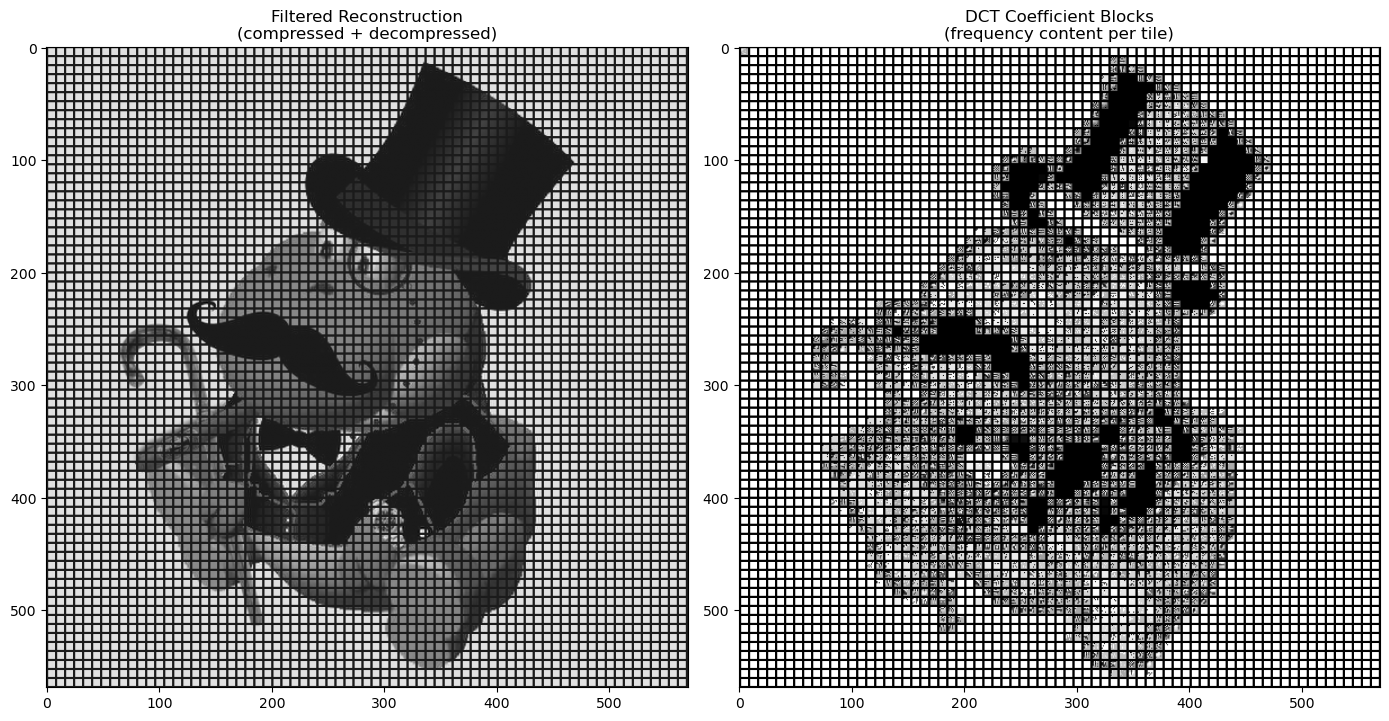

In [40]:
# Initialise blank canvases the same size as the original image
pixels_wow = np.zeros(gray.shape)   # Will hold the reconstructed image
pixels_d   = np.zeros(gray.shape)   # Will hold the DCT coefficient visualisation

for y in range(height):
    for x in range(width):
        # Determine which tile this pixel belongs to
        current_tile = (x // eight, y // eight)

        if current_tile in dct_tiles:
            # Local position within the tile
            local_y, local_x = y % eight, x % eight

            pixels_d[y][x]   = int(dct_tiles[current_tile][local_y][local_x])
            pixels_wow[y][x] = int(new_tiles[current_tile][local_y][local_x])

            # Draw grid lines at tile boundaries
            if local_x <= 1 or local_y <= 1:
                pixels_wow[y][x] = pixels_d[y][x] = 0

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].set_title("Filtered Reconstruction\n(compressed + decompressed)")
axes[0].imshow(pixels_wow, cmap="gray")

axes[1].set_title("DCT Coefficient Blocks\n(frequency content per tile)")
axes[1].imshow(pixels_d, cmap="gray")

plt.tight_layout()
plt.show()
